# Viewing Results from Simulation Runs

This notebook provides a few example functions to view and interact with the images generated from the [CT_dataset_pipeline.py](../CT_dataset_pipeline.py).

To begin, locate the `metadata.csv` output by the simulation run specified by the `base_dir` variable in [CT_dataset_pipeline.py](../CT_dataset_pipeline.py), using Pandas this metadata file enables quickly filtering and working with the images to select the examples of interest.

In [103]:
!ls /gpfs_projects/brandon.nelson/pedsilicoICH/2024-09-15_mixed_datasets_shortscan

case_000  case_004  case_008  case_012	case_016  case_020  case_024
case_001  case_005  case_009  case_013	case_017  case_021  case_025
case_002  case_006  case_010  case_014	case_018  case_022  case_026
case_003  case_007  case_011  case_015	case_019  case_023  case_027


In [105]:
from pathlib import Path

import pandas as pd
import numpy as np

base_dir = Path('/gpfs_projects/brandon.nelson/pedsilicoICH/2024-09-15_mixed_datasets_shortscan')
metadata = pd.concat([pd.read_csv(o) for o in base_dir.rglob('*.csv')], ignore_index=True)
metadata

,name,age,contrast,center x,center y,center z,lesion type,lesion volume [mL],mA,kVp,fov [mm],views,image file,mask file
0,case_012,9.00,[np.int64(169)],275.402594,169.799121,125.954265,['subdural'],4.451955,50,120,250,100,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
1,case_012,9.00,[np.int64(169)],275.402594,169.799121,125.954265,['subdural'],4.451955,50,120,250,100,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
2,case_012,9.00,[np.int64(169)],275.402594,169.799121,125.954265,['subdural'],4.451955,50,120,250,100,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
3,case_012,9.00,[np.int64(169)],275.402594,169.799121,125.954265,['subdural'],4.451955,50,120,250,100,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
4,case_012,9.00,[np.int64(169)],275.402594,169.799121,125.954265,['subdural'],4.451955,50,120,250,100,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4398,case_009,15.75,[np.int64(125)],192.585524,232.904326,24.550941,['epidural'],4.857429,100,110,250,100,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
4399,case_009,15.75,[np.int64(125)],192.585524,232.904326,24.550941,['epidural'],4.857429,100,110,250,100,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
4400,case_009,15.75,[np.int64(125)],192.585524,232.904326,24.550941,['epidural'],4.857429,100,110,250,100,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
4401,case_009,15.75,[np.int64(125)],192.585524,232.904326,24.550941,['epidural'],4.857429,100,110,250,100,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...


## Interactive Viewing using IPywidgets

In [26]:
from pedsilicoICH.image_acquisition import read_dicom
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

from utils import display_settings, browse_studies, study_viewer

In [27]:
study_viewer(metadata)

interactive(children=(Dropdown(description='name', options=('case_000', 'case_001', 'case_002', 'case_003', 'c…

In [9]:
metadata[metadata['name']=='case_005']['age'].unique()

array([15.75])

In [10]:
metadata[metadata['name']=='case_003']['age'].unique()

array([15.75])

In [14]:
{c: float(metadata[metadata['name']==c]['age'].unique()[0]) for c in metadata['name'].unique()}

{'case_000': 9.0,
 'case_001': 9.0,
 'case_002': 6.5,
 'case_003': 15.75,
 'case_004': 10.5,
 'case_005': 15.75,
 'case_006': 12.0}

## Viewing the ground truth ICH segmentation masks

The `mask file` column contains the file location containing the ICH mask associated with each image. 

In [5]:
from utils import load_vol
mask = load_vol(metadata[metadata['name'] == 'case_000']['mask file'])

You can filter by `name` to get the contrast and radius of the lesion (it's a sphere in this instance)

In [6]:
np.unique(metadata[metadata['name'] == 'case_001']['radius']), np.unique(metadata[metadata['name'] == 'case_000']['radius'])

(array([18]), array([5]))

Here's an example of how to get the lesion center coordinates from the mask (note the current `center x`, `center y`, `center z` values in `metadata.csv` refer to the coordinates in object space which don't necesarily equal the coordinates in the reconstructed image space due to the effects of the selected reconstructed field of view and magnification.

In [23]:
from utils import get_lesion_coords

With these coordinates we can center the displayed image at the z slice centered about the lesion.

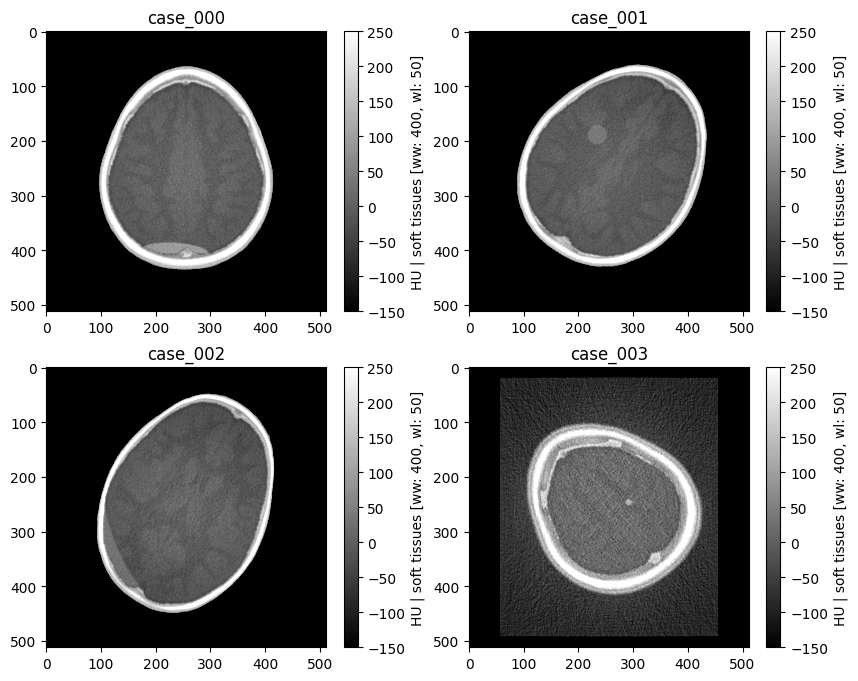

In [24]:
f, axs = plt.subplots(2,2, figsize=(10,8))
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    z, x, y = get_lesion_coords(load_vol(metadata[metadata['name'] == case]['mask file']))
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax)

### Highlighting the lesion location with a bounding box

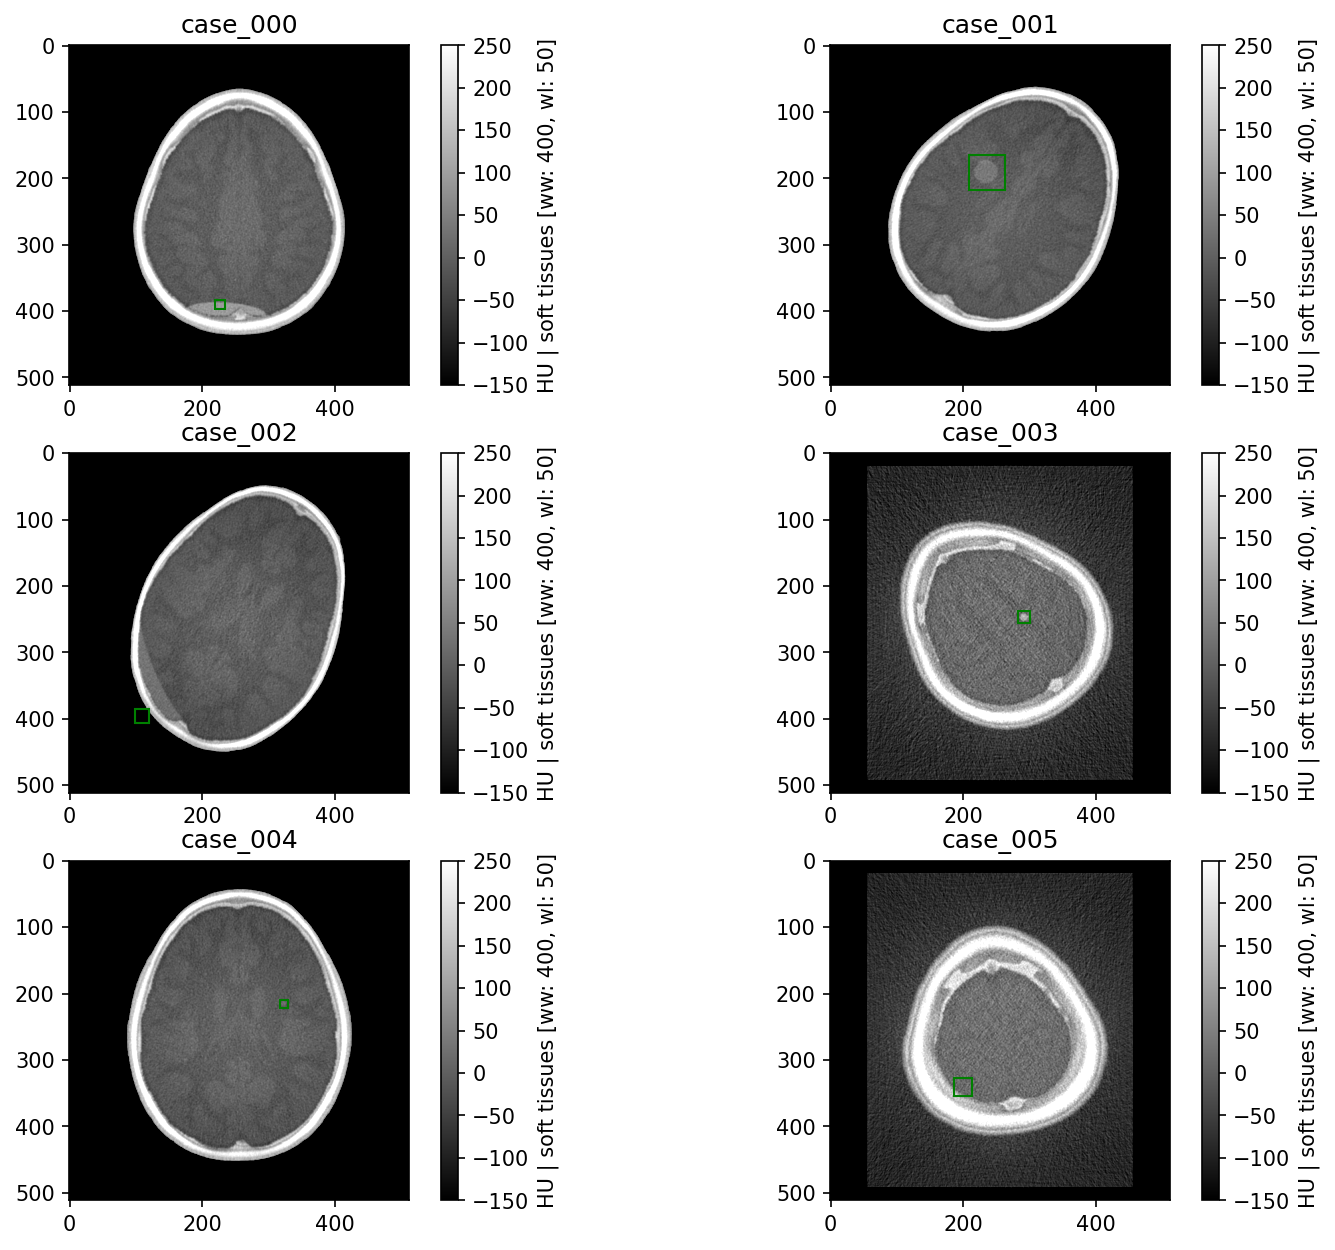

In [34]:
from matplotlib.patches import Rectangle 
nrows = 3
ncols = 2
f, axs = plt.subplots(nrows,ncols, figsize=(nrows*4,ncols*4+2), dpi=150)
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    z, x, y = get_lesion_coords(load_vol(metadata[metadata['name'] == case]['mask file']))
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax)
    width = 3*metadata[metadata['name'] == case]['radius'].unique()[0]
    ax.add_patch(Rectangle((x-width/2, y-width/2), width=width, height=width, fc ='none', ec ='g', lw = 1))

### Highlighting the lesion location with a segmentation mask overlay

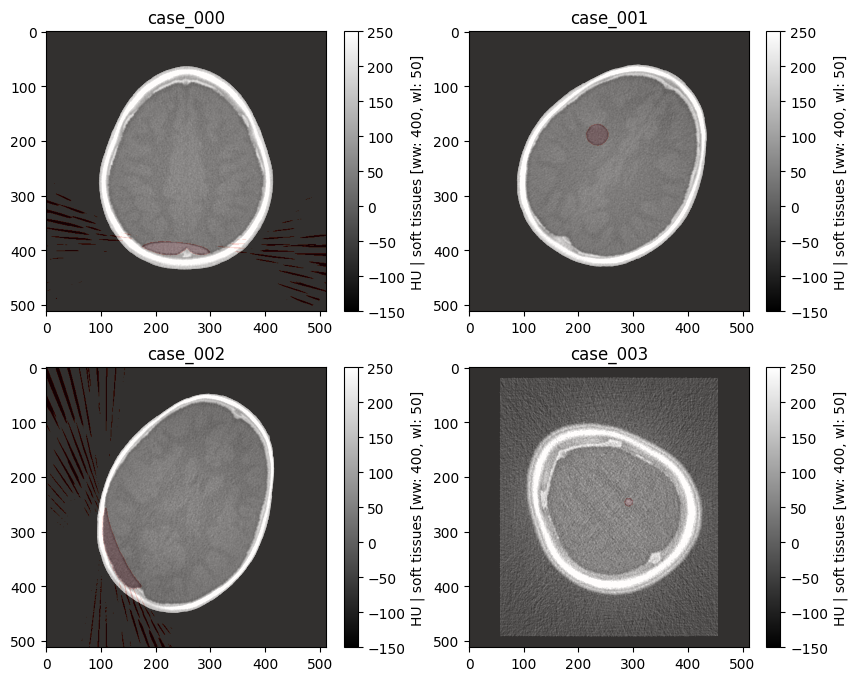

In [26]:
f, axs = plt.subplots(2,2, figsize=(10,8))
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    mask = load_vol(metadata[metadata['name'] == case]['mask file'])
    z, x, y = get_lesion_coords(mask)
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax)
    ax.imshow(mask[z], cmap='Reds', alpha=0.2)

## Reformated Views

In [11]:
from utils import scrollview
vol = load_vol(metadata[metadata['name']=='case_000']['image file'])
mask = load_vol(metadata[metadata['name']=='case_000']['mask file'])

vol.shape, mask.shape

((147, 512, 512), (147, 512, 512))

In [12]:
scrollview(vol)

interactive(children=(IntSlider(value=73, description='idx', max=146), Output()), _dom_classes=('widget-intera…

In [13]:
scrollview(vol.transpose(1,0,2)[:,::-1])

interactive(children=(IntSlider(value=256, description='idx', max=511), Output()), _dom_classes=('widget-inter…

In [14]:
scrollview(vol.transpose(2,0,1)[:, ::-1])

interactive(children=(IntSlider(value=256, description='idx', max=511), Output()), _dom_classes=('widget-inter…

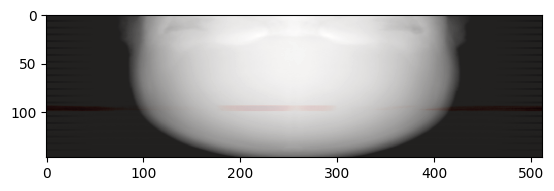

In [15]:
plt.imshow(vol.sum(axis=1), cmap='gray')
plt.imshow(mask.sum(axis=1), cmap='Reds', alpha=0.1)